In [3]:
### Importar Bibliotecas

import pandas as pd
import glob
import os

files = glob.glob("datos/*.xlsx")

files



['datos\\CO.xlsx',
 'datos\\IUV.xlsx',
 'datos\\LLU.xlsx',
 'datos\\NO2.xlsx',
 'datos\\O3.xlsx',
 'datos\\PM10.xlsx',
 'datos\\PM2.5.xlsx',
 'datos\\PRE.xlsx',
 'datos\\RS.xlsx',
 'datos\\SO2.xlsx',
 'datos\\TMP.xlsx',
 'datos\\VEL.xlsx']

In [4]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    # Normalizar nombre de fecha
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long


In [5]:
file_map = {
    'CO.xlsx': 'CO',
    'IUV.xlsx': 'UV_Index',
    'LLU.xlsx': 'Precipitation',
    'NO2.xlsx': 'NO2',
    'O3.xlsx': 'O3',
    'PM10.xlsx': 'PM10',
    'PM2.5.xlsx': 'PM2.5',
    'PRE.xlsx': 'Pressure',
    'RS.xlsx': 'Solar_Radiation',
    'SO2.xlsx': 'SO2',
    'TMP.xlsx': 'Temperature',
    'VEL.xlsx': 'Wind_Velocity'
}


In [10]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    # Forzar formato día/mes/año
    df['Fecha'] = pd.to_datetime(
        df['Fecha'], 
        dayfirst=True, 
        errors='coerce'
    )
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long


In [11]:
from functools import reduce

dfs_long = []

for f in files:
    fname = os.path.basename(f)
    if fname in file_map:
        var_name = file_map[fname]
        df_long = load_and_melt(f, var_name)
        dfs_long.append(df_long)

df_master = reduce(
    lambda left, right: pd.merge(left, right, on=['Fecha','station'], how='outer'),
    dfs_long
)

df_master['date'] = pd.to_datetime(df_master['Fecha'])
df_master = df_master.drop(columns=['Fecha'])

df_master = df_master.sort_values(['station','date']).reset_index(drop=True)

df_master.head()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_43992\612561.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(


,station,CO,UV_Index,Precipitation,NO2,O3,PM10,PM2.5,Pressure,Solar_Radiation,SO2,Temperature,Wind_Velocity,date
0,BELISARIO,NaN,NaN,NaN,NaN,42.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:00:00
1,BELISARIO,NaN,NaN,NaN,NaN,59.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 01:00:00
2,BELISARIO,NaN,NaN,NaN,NaN,61.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 02:00:00
3,BELISARIO,NaN,NaN,NaN,NaN,71.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 03:00:00
4,BELISARIO,NaN,NaN,NaN,NaN,37.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 04:00:00


In [13]:
df_master[['date']].describe()
df_master['date'].isna().sum()


np.int64(1)

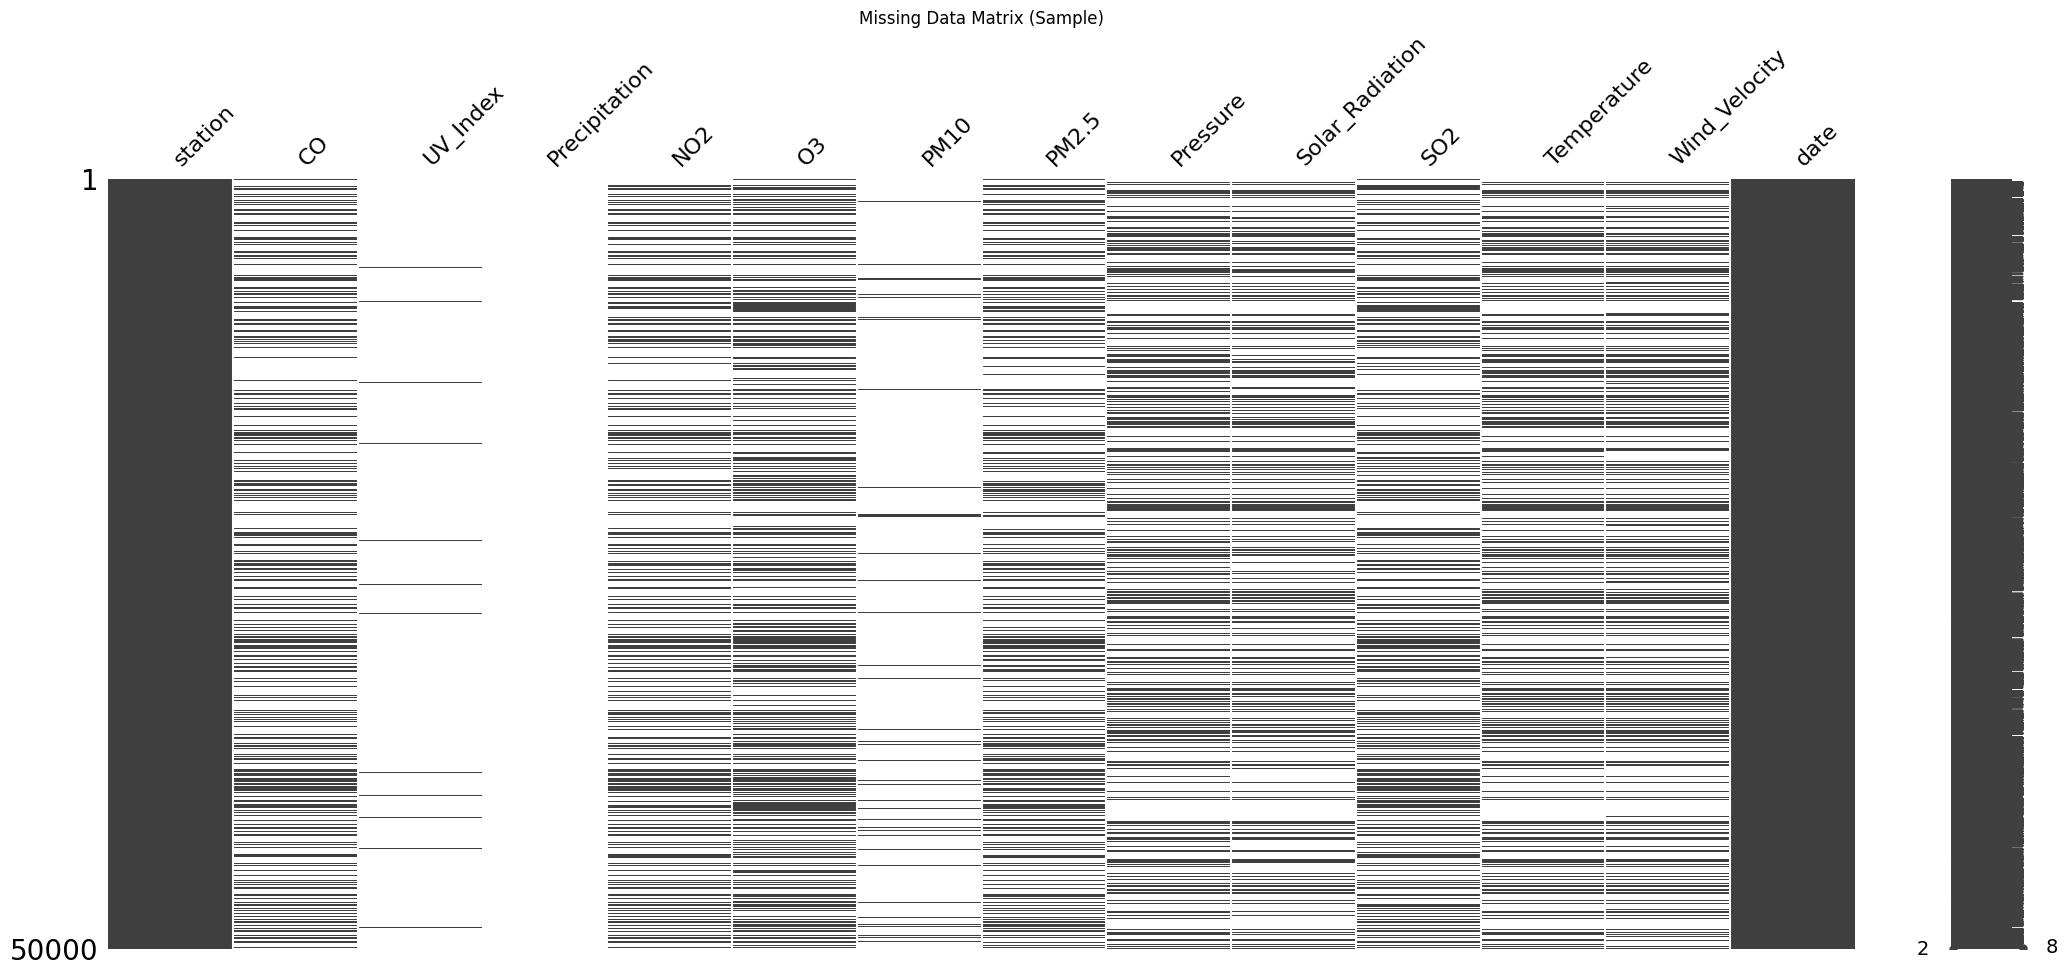

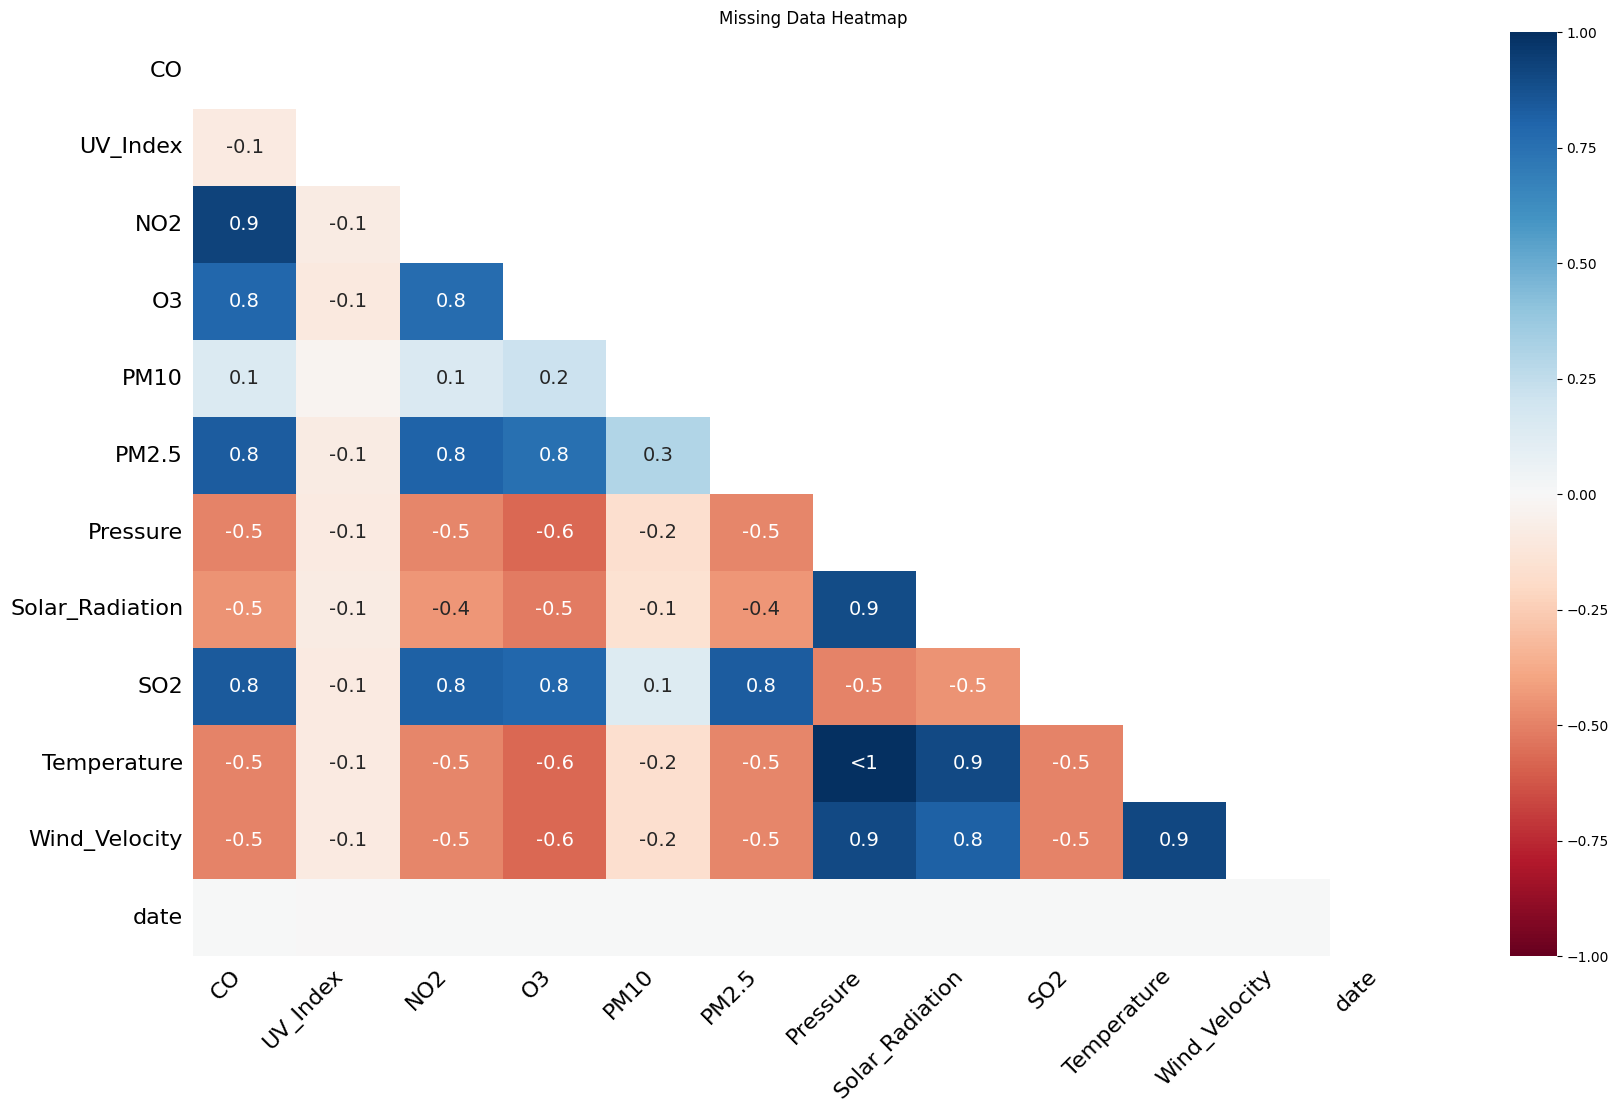

In [15]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df_master.sample(50000))  # sample para que no sea gigante
plt.title("Missing Data Matrix (Sample)")
plt.show()

msno.heatmap(df_master)
plt.title("Missing Data Heatmap")
plt.show()


In [16]:
missing_pct = df_master.isna().mean().sort_values(ascending=False)
missing_pct

Precipitation      1.000000e+00
UV_Index           9.840033e-01
PM10               9.506207e-01
Solar_Radiation    6.954862e-01
NO2                6.940148e-01
PM2.5              6.918413e-01
CO                 6.858321e-01
SO2                6.833171e-01
Wind_Velocity      6.519833e-01
Pressure           6.514147e-01
Temperature        6.501874e-01
O3                 6.203348e-01
date               2.675749e-07
station            0.000000e+00
dtype: float64